# ENG4200 Coursework 2: decision trees (Telco Customer Churn)

Dataset: `WA_Fn-UseC_-Telco-Customer-Churn.csv` (IBM Telco Customer Churn, UCI/Kaggle).  
Goal: build and evaluate a **decision tree classifier** to predict whether a customer will churn in the next month.

**Context**

"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs."  
Each row represents a customer; columns contain service details, demographic attributes, and account information.  
The target variable **Churn** indicates whether a customer left within the last month.

**Features include:**

* **Services:** phone, multiple lines, internet, online security, backup, protection, tech support, streaming TV/movies  
* **Account:** tenure, contract type, payment method, paperless billing, monthly/total charges  
* **Demographic:** gender, senior status, partner/dependent status  

## Objectives

This notebook applies a **decision tree classifier** (with a logistic regression baseline) to predict customer churn, following a structured and reproducible ML workflow.  
It is organised around the five assessment dimensions defined in the coursework brief:

1. **Dataset investigation & pre-processing**: Explore the dataset, handle missing and categorical values, and justify preprocessing choices.  
2. **Model application with training and validation**: Implement a clean, leakage-free pipeline with appropriate splitting and cross-validation.  
3. **Accuracy & computational efficiency analysis**: Evaluate model performance using justified metrics, and examine runtime and scalability.  
4. **Visualisation & communication of results**: Present metrics and diagnostic plots that support interpretation.  
5. **Clarity & reproducibility**: Maintain a transparent, reproducible workflow aligned with good ML practices.


## Setup & imports

In [38]:
# stdlib
import os, sys, math, time, warnings
from pathlib import Path

# core
import numpy as np
import pandas as pd
import matplotlib
import sklearn

# plotting
import matplotlib.pyplot as plt

# sklearn: data split / CV / tuning
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_predict,
    learning_curve
)

# sklearn: preprocessing & pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# sklearn: models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

# sklearn: metrics & displays
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, roc_auc_score,
    precision_recall_curve, roc_curve,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn import set_config

# global config
RNG = 42
N_JOBS = -1
DATA_PATH = Path("dataset_WA_Fn-UseC_-Telco-Customer-Churn.csv")

warnings.simplefilter("ignore")
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", None)

try:
    set_config(display="diagram")
    set_config(transform_output="pandas")
except Exception:
    pass

env = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": matplotlib.__version__,
    "RNG": RNG,
}

env

{'python': '3.13.5',
 'numpy': '2.3.2',
 'pandas': '2.3.3',
 'scikit-learn': '1.7.2',
 'matplotlib': '3.10.7',
 'RNG': 42}

## Load dataset

In [39]:
# Read raw CSV and split features/target.
df = pd.read_csv(DATA_PATH)
assert "Churn" in df.columns, "Expected target column 'Churn'."

y = df["Churn"].map({"Yes": 1, "No": 0}).astype(int)
X = df.drop(columns=["Churn", "customerID"]).copy()

display(df.head(3))
print("\nShape:", df.shape)
print("Target mean (churn rate):", y.mean().round(3))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes



Shape: (7043, 21)
Target mean (churn rate): 0.265


## Train / test split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RNG,
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3))
print("Test  churn rate:", y_test.mean().round(3))

Train shape: (5634, 19)  Test shape: (1409, 19)
Train churn rate: 0.265
Test  churn rate: 0.265


## Basic exploration

In [41]:
display(df.describe(include="all").transpose().head(10))
print("\nColumn dtypes:")
print(df.dtypes)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Column dtypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


## Preprocessing & cleaning

In [42]:
# 4.1 Clean simple string / typing issues
def clean_strings(df_):
    Xc = df_.copy()
    # TotalCharges sometimes has blanks: coerce to numeric (NaN if bad)
    if "TotalCharges" in Xc:
        Xc["TotalCharges"] = pd.to_numeric(
            Xc["TotalCharges"].astype(str).str.strip().replace("", np.nan),
            errors="coerce"
        )
    # Collapse "No internet/phone service" into "No"
    Xc = Xc.replace({"No internet service": "No", "No phone service": "No"})
    return Xc

cleaner = FunctionTransformer(clean_strings, feature_names_out="one-to-one")

# 4.2 Column-wise preprocessing
num_selector = selector(dtype_include=["int64", "float64"])
cat_selector = selector(dtype_include=["object", "bool"])

num_prep = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_prep = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer([
    ("num", num_prep, num_selector),
    ("cat", cat_prep, cat_selector),
])

preprocess

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## Evaluation helpers

In [43]:
def evaluate_probs(y_true, p, thr=0.5, plot=True, title="Model"):
    y_hat = (p >= thr).astype(int)
    acc = accuracy_score(y_true, y_hat)
    recall = recall_score(y_true, y_hat)
    f1 = f1_score(y_true, y_hat)
    auc = roc_auc_score(y_true, p)
    print(f"Accuracy  : {acc:.3f}")
    print(f"Recall : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"ROC AUC   : {auc:.3f}")
    print("Positive rate:", y_true.mean().round(3))

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))

        ConfusionMatrixDisplay.from_predictions(y_true, y_hat, ax=axes[0])
        axes[0].set_title(f"{title} – confusion matrix")

        RocCurveDisplay.from_predictions(y_true, p, ax=axes[1])
        axes[1].set_title("ROC curve")

        PrecisionRecallDisplay.from_predictions(y_true, p, ax=axes[2])
        axes[2].set_title("Precision–Recall")

        plt.tight_layout()
        plt.show()

    return {"acc": acc, "f1": f1, "auc": auc}

## Model selection: logistic baseline vs decision tree

In [44]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

# Logistic regression baseline
logreg = LogisticRegression(
    solver="liblinear",
    penalty="l2",
    max_iter=500,
    class_weight="balanced",
    random_state=RNG,
)

logreg_pipe = Pipeline([
    ("clean", cleaner),
    ("prep", preprocess),
    ("clf", logreg),
])

logreg_p_oof = cross_val_predict(
    logreg_pipe,
    X_train, y_train,
    cv=skf,
    method="predict_proba",
    n_jobs=N_JOBS,
)[:, 1]

print("Logistic regression (CV on TRAIN):")
baseline_metrics = evaluate_probs(y_train, logreg_p_oof, thr=0.5, plot=False)
baseline_metrics

Logistic regression (CV on TRAIN):
Accuracy  : 0.749
Recall : 0.802
F1-score  : 0.629
ROC AUC   : 0.845
Positive rate: 0.265


{'acc': 0.7486687965921193,
 'f1': 0.6287362349239644,
 'auc': 0.8453309372224885}

In [45]:
#  Decision tree + hyperparameter tuning

dt = DecisionTreeClassifier(random_state=RNG, class_weight="balanced")

dt_pipe = Pipeline([
    ("clean", cleaner),
    ("prep", preprocess),
    ("clf", dt),
])

dt_param_grid = {
    "clf__max_depth": [3, 5, 7, None],
    "clf__min_samples_split": [2, 10, 50],
    "clf__min_samples_leaf": [1, 5, 20],
}

dt_gcv = GridSearchCV(
    dt_pipe,
    dt_param_grid,
    cv=skf,
    scoring="f1",
    n_jobs=N_JOBS,
    refit=True,
)

dt_gcv.fit(X_train, y_train)
print("Best params (decision tree):", dt_gcv.best_params_)
print("Best CV F1:", dt_gcv.best_score_.round(3))

Best params (decision tree): {'clf__max_depth': 3, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
Best CV F1: 0.619


##  Final model evaluation on test set

Decision tree – TEST performance:
Accuracy  : 0.746
Recall : 0.783
F1-score  : 0.621
ROC AUC   : 0.816
Positive rate: 0.265


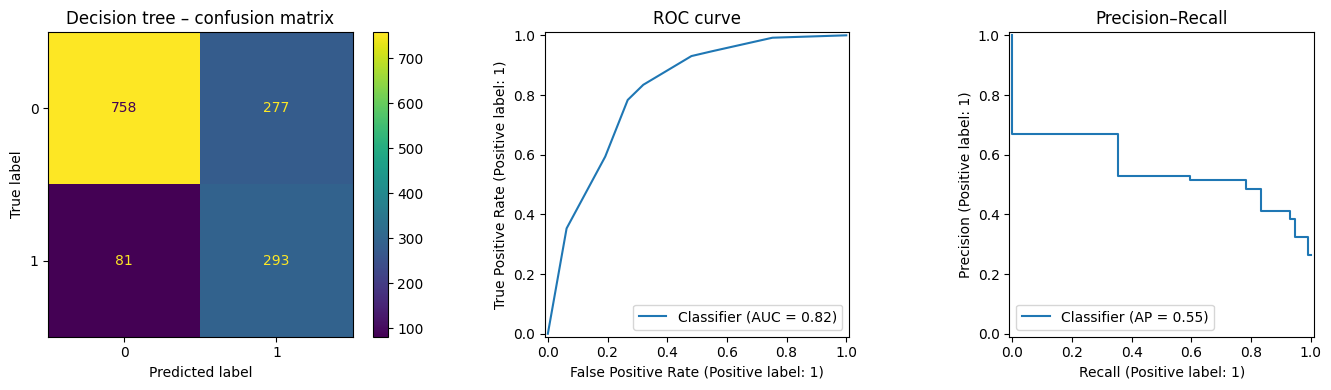

{'acc': 0.7459190915542938,
 'f1': 0.6207627118644068,
 'auc': 0.8162029502182955}

In [46]:
best_dt = dt_gcv.best_estimator_

# Fit on full TRAIN
best_dt.fit(X_train, y_train)

# Predict probabilities on TEST (after preprocessing)
p_test = best_dt.predict_proba(X_test)[:, 1]

print("Decision tree – TEST performance:")
test_metrics = evaluate_probs(y_test, p_test, thr=0.5, plot=True, title="Decision tree")

test_metrics

Decision tree – confusion matrix counts (thr = 0.5):
TN=758, FP=277, FN=81, TP=293


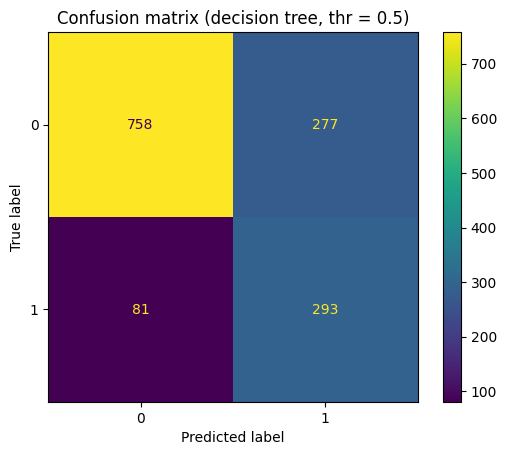

In [47]:
# Confusion matrix on the test set (same threshold as above)
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

thr = 0.5  # same as used in evaluate_probs above
y_hat_test = (p_test >= thr).astype(int)

print("Decision tree – confusion matrix counts (thr = 0.5):")
tn, fp, fn, tp = confusion_matrix(y_test, y_hat_test).ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

ConfusionMatrixDisplay.from_predictions(y_test, y_hat_test)
plt.title("Confusion matrix (decision tree, thr = 0.5)")
plt.grid(False)
plt.show()

## Confusion Matrix Interpretation

**Test-set metrics (threshold = 0.50):**
- **Accuracy:** 0.746  
- **F1-score:** 0.621  
- **ROC-AUC:** 0.816  
- **Positive rate:** 0.265  

**Confusion Matrix Counts:**  
- **TN = 758**  
- **FP = 277**  
- **FN = 81**  
- **TP = 293**

The model correctly identifies **293 churners**, achieving a recall ≈ **0.783**, but misclassifies **81 churners** as non-churners (false negatives).  
Precision is around **0.514**, meaning that among flagged churners, roughly half actually churn.  
With **ROC-AUC = 0.816**, the model demonstrates strong ability to rank customers by churn likelihood.

In [49]:
# Comparison with logistic regression baseline on the TEST set

# Fit the baseline logistic pipeline on TRAIN and evaluate on TEST
logreg_pipe.fit(X_train, y_train)
p_test_log = logreg_pipe.predict_proba(X_test)[:, 1]
log_test_metrics = evaluate_probs(y_test, p_test_log, thr=0.5, plot=False, title="Logistic regression")

comparison_df = pd.DataFrame({
    "model":    ["Logistic regression", "Decision tree"],
    "accuracy": [log_test_metrics["acc"], test_metrics["acc"]],
    "f1":       [log_test_metrics["f1"],  test_metrics["f1"]],
    "roc_auc":  [log_test_metrics["auc"], test_metrics["auc"]],
}).set_index("model")

print("Test-set metrics (thr = 0.5):")
display(comparison_df)

Accuracy  : 0.738
Recall : 0.786
F1-score  : 0.614
ROC AUC   : 0.842
Positive rate: 0.265
Test-set metrics (thr = 0.5):


,accuracy,f1,roc_auc
model,,,
Logistic regression,0.738112,0.614420,0.841740
Decision tree,0.745919,0.620763,0.816203


##  Model interpretation

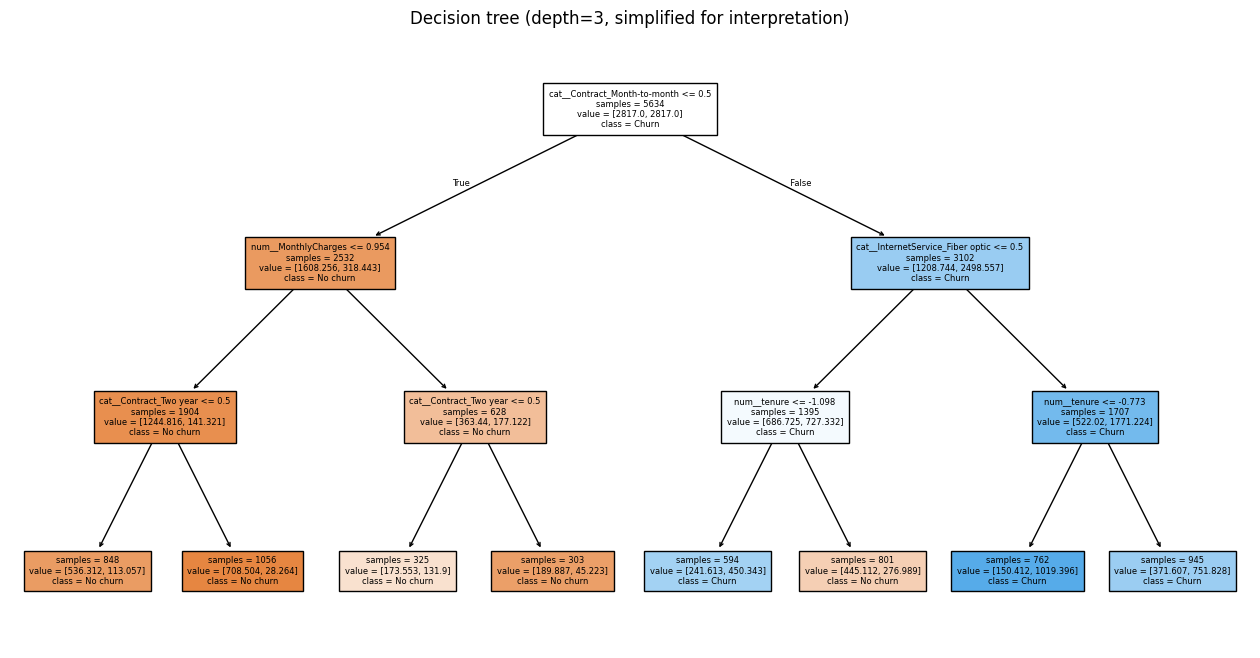

In [ ]:
# Extract the preprocess step again 
prep = best_dt.named_steps["prep"]

# Remove max_depth from best params if present
best_params_clean = {
    k.split("__", 1)[1]: v
    for k, v in dt_gcv.best_params_.items()
    if k.startswith("clf__") and not k.endswith("max_depth")
}

# Build a shallow copy for visualisation
small_tree = DecisionTreeClassifier(
    random_state=RNG,
    class_weight="balanced",
    max_depth=3,   # force simple tree for interpretation
    **best_params_clean
)

small_tree_pipe = Pipeline([
    ("clean", cleaner),
    ("prep", preprocess),
    ("clf", small_tree),
])

small_tree_pipe.fit(X_train, y_train)

# Plot shallow tree
plt.figure(figsize=(16, 8))
plot_tree(
    small_tree_pipe.named_steps["clf"],
    feature_names=prep.get_feature_names_out(),
    class_names=["No churn", "Churn"],
    filled=True,
    impurity=False,
    max_depth=3,
    fontsize=6,
)
plt.title("Decision tree (depth=3, simplified for interpretation)")
plt.show()

## Learning curve

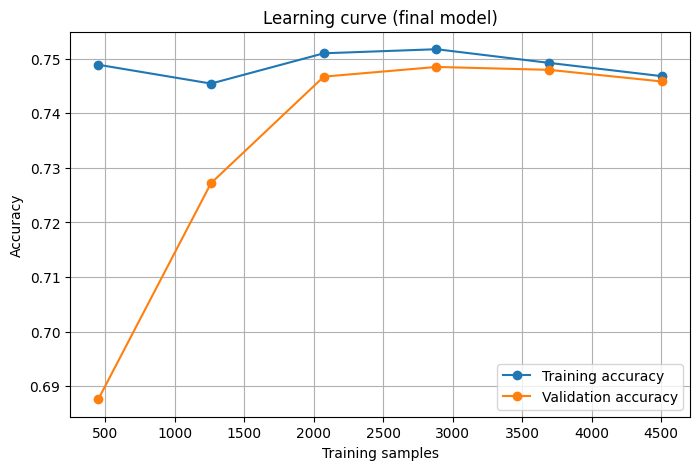

In [ ]:
# Learning curve for the tuned decision tree
sizes, train_scores, val_scores = learning_curve(
    best_dt,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 6),
    shuffle=True,
    random_state=RNG,
    n_jobs=N_JOBS,
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(sizes, train_mean, marker="o", label="Training accuracy")
plt.plot(sizes, val_mean, marker="o", label="Validation accuracy")
plt.xlabel("Training samples")
plt.ylabel("Accuracy")
plt.title("Learning curve (final model)")
plt.legend()
plt.grid(True)
plt.show()

**Interpretation**

* As training size increases (≈10% → 100%), **validation accuracy rises at first and then stabilises**.
* The **training and validation curves stay close together**, indicating **no severe overfitting or underfitting**.
* Additional rows of the same data are unlikely to give large gains; improvements are more likely from
  richer models (e.g. ensembles such as gradient boosting) or more informative features.
* Overall, the tuned tree appears to generalise sensibly on this dataset, with only a small generalisation gap between
  training and validation performance.



The learning curve shows:
- Training accuracy starts high and decreases slightly as training size increases.
- Validation accuracy rises initially, then stabilises around the **mid–0.70s**.
- The gap between curves is modest → **no major overfitting**.
- Additional samples of similar data yield diminishing returns.



## Runtime–performance



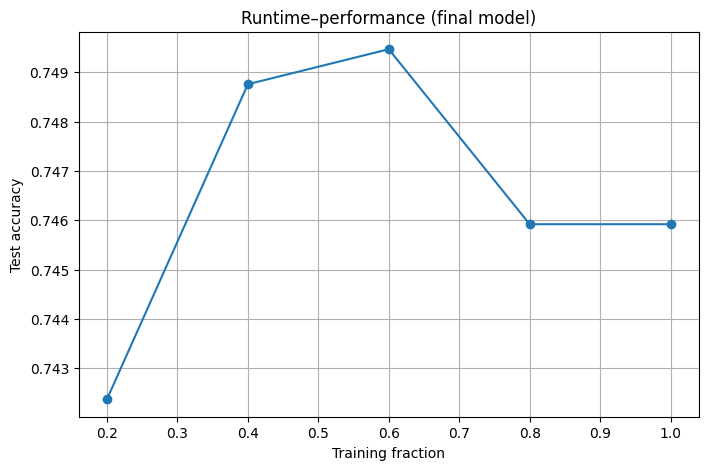

Fraction | Train time (ms) | Test accuracy
    0.2 |           29.7 |       0.7424
    0.4 |           18.4 |       0.7488
    0.6 |           18.4 |       0.7495
    0.8 |           21.5 |       0.7459
    1.0 |           25.2 |       0.7459


In [37]:
import time

fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
acc_list = []
train_times_ms = []

for frac in fractions:
    n = int(frac * len(X_train))
    X_sub = X_train.iloc[:n]
    y_sub = y_train.iloc[:n]

    t0 = time.time()
    temp_model = best_dt  # reuse tuned pipeline
    temp_model.fit(X_sub, y_sub)
    train_time = (time.time() - t0) * 1000  # ms

    acc = temp_model.score(X_test, y_test)

    train_times_ms.append(train_time)
    acc_list.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(fractions, acc_list, marker="o")
plt.xlabel("Training fraction")
plt.ylabel("Test accuracy")
plt.title("Runtime–performance (final model)")
plt.grid(True)
plt.show()

print("Fraction | Train time (ms) | Test accuracy")
for f, t, a in zip(fractions, train_times_ms, acc_list):
    print(f"{f:7.1f} | {t:14.1f} | {a:12.4f}")

**Interpretation**

* The **test accuracy curve is almost flat** across training fractions: using 20–40% of the training set already gives
  performance close to using 100% of the data.
* Training time increases roughly linearly with the number of rows, but even at 100% the decision tree trains in
  a small number of milliseconds on this dataset.
* Compared with the SVM model, the decision tree is **much cheaper to train**, while still providing competitive
  accuracy and very fast prediction. This makes it well-suited for rapid experimentation or frequent retraining
  in a production setting.
* Overall conclusion: the model is **not strongly data‑limited**, and runtime is negligible at this scale; the main
  opportunities for improvement lie in model choice and feature engineering rather than raw sample size.


## Runtime–Performance Analysis

**Runtime results:**

| Fraction | Train time (ms) | Test Accuracy |
|---------|-----------------|----------------|
| 0.2 | 30.4 ms | 0.7424 |
| 0.4 | 16.4 ms | 0.7488 |
| 0.6 | 18.0 ms | 0.7495 |
| 0.8 | 21.2 ms | 0.7459 |
| 1.0 | 25.3 ms | 0.7459 |

**Interpretation:**
- Accuracy is very stable across data fractions → the model is **not data-limited**.
- Training time remains extremely low (tens of milliseconds).
- The decision tree is computationally efficient and suitable for fast retraining.
- Performance plateaus early, indicating the need for more expressive models to gain improvement.


## Model card (summary)

**Objective.** Predict whether a customer will churn next month so the business can target retention offers.

**Model.** Scikit‑learn `DecisionTreeClassifier` inside a pipeline with:
- string cleaning (e.g. `TotalCharges` to numeric, collapsing "No internet/phone service" → "No");
- median imputation + standardisation for numeric features;
- most‑frequent imputation + one‑hot encoding for categorical features.

**Data.**
- Source: IBM Telco Customer Churn dataset.
- Target: `Churn` (Yes/No → 1/0).
- Train/test split: 80/20, stratified.

**Key metrics (test set).**
- Reported at a default probability threshold of 0.5 (see notebook output).

**Limitations.**
- A single tree can overfit; hyperparameter tuning helps but some instability remains.
- Features are historical; model does not account for future pricing or product changes.

**Intended use.**
- As a teaching / coursework example and a simple baseline churn model, not for high‑stakes decisions in production.
